<a href="https://colab.research.google.com/github/19942024/Proyecto-pronostico-demanda-/blob/main/Pronostico_Demanda_Yogurt_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRONÓSTICO DE DEMANDA DE YOGURT EN PYTHON





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Cargar el Excel

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/PROYECTO PRONOSTICO /Pronosticos_Yogurt_Excel (1).xlsx"

Mounted at /content/drive


In [3]:
df = pd.read_excel(
    ruta,
    sheet_name="Datos_Detalle",
    header=2
)

## 3. Revisar los datos

In [4]:
df.head()

,Month,SKU_ID,SKU_Name,Category,CEDIS,Provincia,Region,Actual_Sales,Selling_Price_USD,Promotional_Flag,Promotional_Type,Date_Value,Revenue_USD,Promo_Month,Holiday_Month_Flag,Avg_Temperature_C,Inventory_Level,Lead_Time_Days
0,ene-2021,YG-001,Yogurt Bebible Fresa 1L,Bebible,CEDIS Ambato,Chimborazo,Sierra,147,2.15,No,NaN,2021-01-01,316.05,0,1,18.0,379,5
1,ene-2021,YG-002,Yogurt Bebible Mora 1L,Bebible,CEDIS Ambato,Chimborazo,Sierra,141,2.15,No,NaN,2021-01-01,303.15,0,1,15.4,351,4
2,ene-2021,YG-003,Yogurt Bebible Durazno 6x200ml,Bebible,CEDIS Ambato,Chimborazo,Sierra,79,3.10,No,NaN,2021-01-01,244.90,0,1,17.5,247,5
3,ene-2021,YG-004,Yogurt Griego Natural 150g,Griego,CEDIS Ambato,Chimborazo,Sierra,83,1.45,No,NaN,2021-01-01,120.35,0,1,15.6,163,2
4,ene-2021,YG-005,Yogurt Griego Frutos Rojos 150g,Griego,CEDIS Ambato,Chimborazo,Sierra,62,1.55,No,NaN,2021-01-01,96.10,0,1,17.1,151,2


In [5]:
df.shape

(4992, 18)

In [6]:
df.columns

Index(['Month', 'SKU_ID', 'SKU_Name', 'Category', 'CEDIS', 'Provincia',
       'Region', 'Actual_Sales', 'Selling_Price_USD', 'Promotional_Flag',
       'Promotional_Type', 'Date_Value', 'Revenue_USD', 'Promo_Month',
       'Holiday_Month_Flag', 'Avg_Temperature_C', 'Inventory_Level',
       'Lead_Time_Days'],
      dtype='object')

## 4. Revisar valores vacíos

In [7]:
df.isna().sum()

,0
Month,0
SKU_ID,0
SKU_Name,0
Category,0
CEDIS,0
Provincia,0
Region,0
Actual_Sales,0
Selling_Price_USD,0
Promotional_Flag,0


`Promotional_Type` tiene valores vacíos porque esos registros corresponden a productos sin promoción.

In [8]:
df["Promotional_Type"] = df["Promotional_Type"].fillna("Sin Promoción")

In [9]:
df["Promotional_Type"].value_counts()

,count
Promotional_Type,
Sin Promoción,3738
Descuento de Precio,279
Combo Familiar,255
Cupon Digital,252
2x1,242
Exhibicion Especial,226


## 5. Preparar la fecha

In [10]:
df["Date_Value"] = pd.to_datetime(df["Date_Value"])
df = df.sort_values("Date_Value")

## 6. Crear la demanda mensual

In [11]:
demanda = (
    df.groupby("Date_Value")["Actual_Sales"]
      .sum()
      .reset_index()
)

demanda.head()

,Date_Value,Actual_Sales
0,2021-01-01,18499
1,2021-02-01,19298
2,2021-03-01,18479
3,2021-04-01,17421
4,2021-05-01,16695


## 7. Graficar la demanda histórica

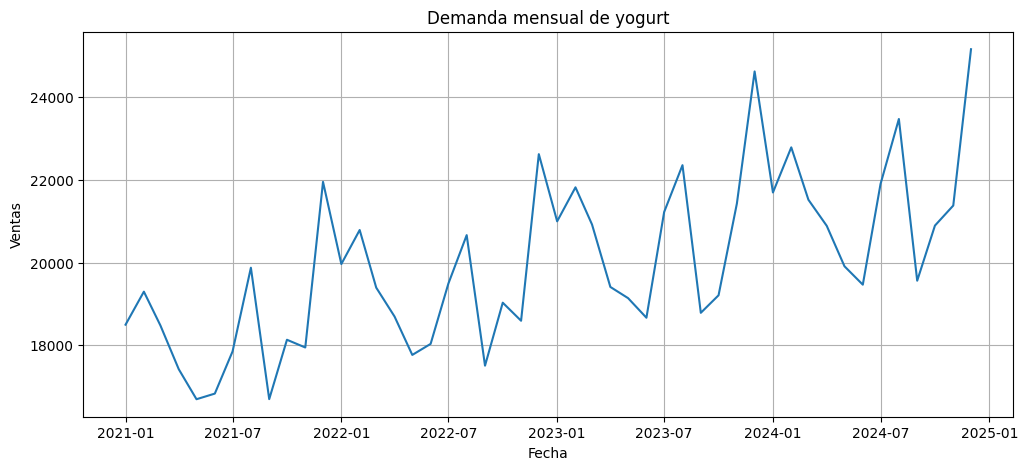

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    demanda["Date_Value"],
    demanda["Actual_Sales"]
)

plt.title("Demanda mensual de yogurt")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid()
plt.show()

## 8. Separar entrenamiento y prueba

2021–2023 será entrenamiento y 2024 será prueba.

In [13]:
train = demanda[demanda["Date_Value"] < "2024-01-01"].copy()
test = demanda[demanda["Date_Value"] >= "2024-01-01"].copy()

print("Meses de entrenamiento:", len(train))
print("Meses de prueba:", len(test))

Meses de entrenamiento: 36
Meses de prueba: 12


# MODELO 1 — NAIVE

El pronóstico será igual al último valor observado.

In [14]:
ultimo_valor = train["Actual_Sales"].iloc[-1]

pronostico_naive = []

for i in range(len(test)):
    pronostico_naive.append(ultimo_valor)

test_naive = test.copy()
test_naive["Pronostico"] = pronostico_naive

### Gráfico

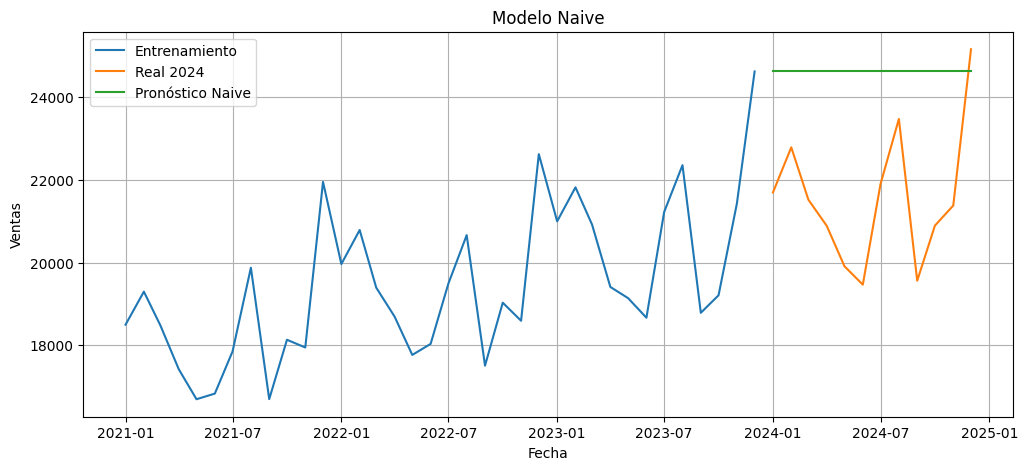

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    train["Date_Value"],
    train["Actual_Sales"],
    label="Entrenamiento"
)

plt.plot(
    test_naive["Date_Value"],
    test_naive["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_naive["Date_Value"],
    test_naive["Pronostico"],
    label="Pronóstico Naive"
)

plt.title("Modelo Naive")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [16]:
error = test_naive["Actual_Sales"] - test_naive["Pronostico"]
error_absoluto = abs(error)

mae_naive = error_absoluto.mean()
rmse_naive = np.sqrt((error ** 2).mean())
mape_naive = (error_absoluto / test_naive["Actual_Sales"]).mean() * 100
wape_naive = (error_absoluto.sum() / test_naive["Actual_Sales"].sum()) * 100

print("MAE:", mae_naive)
print("RMSE:", rmse_naive)
print("MAPE:", mape_naive)
print("WAPE:", wape_naive)

MAE: 3160.9166666666665
RMSE: 3458.292027865779
MAPE: 15.202460866274917
WAPE: 14.663914114176805


# MODELO 2 — SEASONAL NAIVE

Utiliza el mismo mes del año anterior. Como los datos son mensuales, usamos una estacionalidad de 12 meses.

In [17]:
pronostico_seasonal = []

for i in range(len(test)):
    valor = train["Actual_Sales"].iloc[i]
    pronostico_seasonal.append(valor)

test_seasonal = test.copy()
test_seasonal["Pronostico"] = pronostico_seasonal

### Gráfico

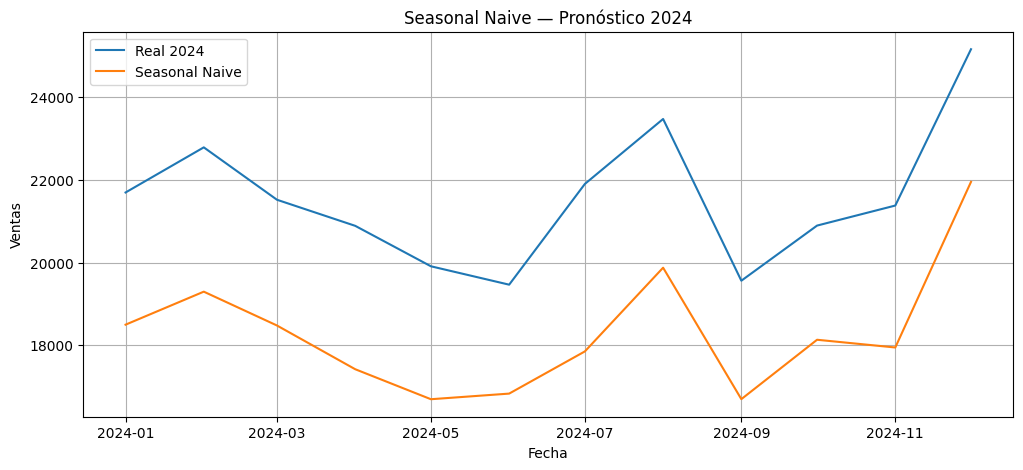

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    test_seasonal["Date_Value"],
    test_seasonal["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_seasonal["Date_Value"],
    test_seasonal["Pronostico"],
    label="Seasonal Naive"
)

plt.title("Seasonal Naive — Pronóstico 2024")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [19]:
error = test_seasonal["Actual_Sales"] - test_seasonal["Pronostico"]
error_absoluto = abs(error)

mae_seasonal = error_absoluto.mean()
rmse_seasonal = np.sqrt((error ** 2).mean())
mape_seasonal = (error_absoluto / test_seasonal["Actual_Sales"]).mean() * 100
wape_seasonal = (error_absoluto.sum() / test_seasonal["Actual_Sales"].sum()) * 100

print("MAE:", mae_seasonal)
print("RMSE:", rmse_seasonal)
print("MAPE:", mape_seasonal)
print("WAPE:", wape_seasonal)

MAE: 3248.5833333333335
RMSE: 3270.5384240723015
MAPE: 15.086428811511535
WAPE: 15.070611476442867


# MODELO 3 — PROMEDIO MÓVIL

Usaremos el promedio de los últimos 3 meses.

In [20]:
ventana = 3

valores = train["Actual_Sales"].values
pronostico_ma = []

for i in range(len(test)):
    promedio = valores[-ventana:].mean()
    pronostico_ma.append(promedio)
    valores = np.append(valores, promedio)

test_ma = test.copy()
test_ma["Pronostico"] = pronostico_ma

### Gráfico

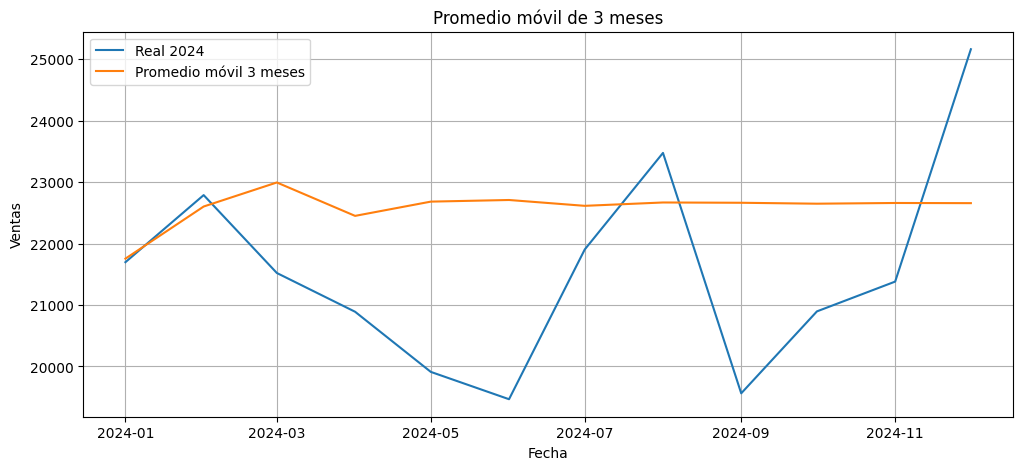

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ma["Date_Value"],
    test_ma["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_ma["Date_Value"],
    test_ma["Pronostico"],
    label="Promedio móvil 3 meses"
)

plt.title("Promedio móvil de 3 meses")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [22]:
error = test_ma["Actual_Sales"] - test_ma["Pronostico"]
error_absoluto = abs(error)

mae_ma = error_absoluto.mean()
rmse_ma = np.sqrt((error ** 2).mean())
mape_ma = (error_absoluto / test_ma["Actual_Sales"]).mean() * 100
wape_ma = (error_absoluto.sum() / test_ma["Actual_Sales"].sum()) * 100

print("MAE:", mae_ma)
print("RMSE:", rmse_ma)
print("MAPE:", mape_ma)
print("WAPE:", wape_ma)

MAE: 1620.9919230607602
RMSE: 1928.304085246838
MAPE: 7.737751906781772
WAPE: 7.519997787415238


# MODELO 4 — SUAVIZAMIENTO EXPONENCIAL SIMPLE

Da más importancia a los datos recientes.

In [23]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

modelo_ses = SimpleExpSmoothing(
    train["Actual_Sales"],
    initialization_method="estimated"
).fit()

pronostico_ses = modelo_ses.forecast(len(test))

test_ses = test.copy()
test_ses["Pronostico"] = pronostico_ses.values

### Gráfico

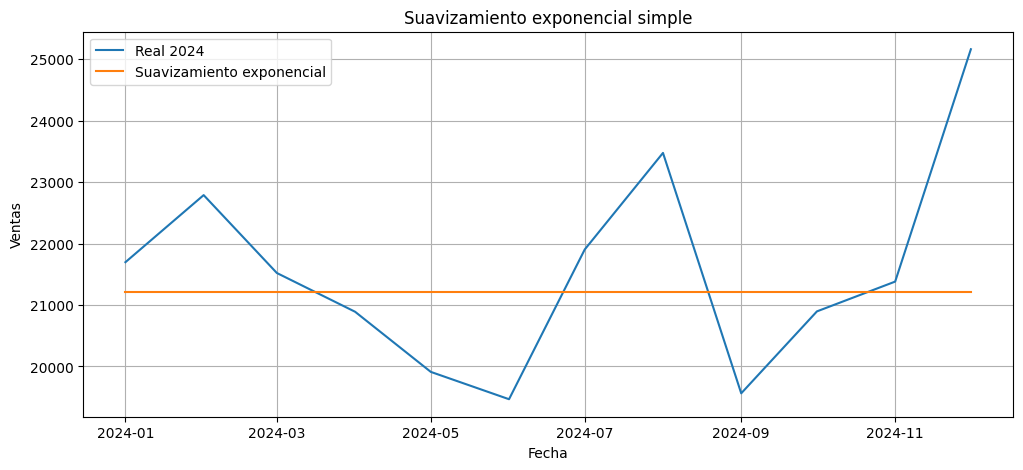

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    test_ses["Date_Value"],
    test_ses["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_ses["Date_Value"],
    test_ses["Pronostico"],
    label="Suavizamiento exponencial"
)

plt.title("Suavizamiento exponencial simple")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [25]:
error = test_ses["Actual_Sales"] - test_ses["Pronostico"]
error_absoluto = abs(error)

mae_ses = error_absoluto.mean()
rmse_ses = np.sqrt((error ** 2).mean())
mape_ses = (error_absoluto / test_ses["Actual_Sales"]).mean() * 100
wape_ses = (error_absoluto.sum() / test_ses["Actual_Sales"].sum()) * 100

print("MAE:", mae_ses)
print("RMSE:", rmse_ses)
print("MAPE:", mape_ses)
print("WAPE:", wape_ses)

MAE: 1231.040427806215
RMSE: 1625.1487378607603
MAPE: 5.570463772062273
WAPE: 5.710960777547591


# MODELO 5 — HOLT

Holt permite considerar una tendencia.

In [26]:
from statsmodels.tsa.holtwinters import Holt

modelo_holt = Holt(
    train["Actual_Sales"],
    initialization_method="estimated"
).fit()

pronostico_holt = modelo_holt.forecast(len(test))

test_holt = test.copy()
test_holt["Pronostico"] = pronostico_holt.values

### Gráfico

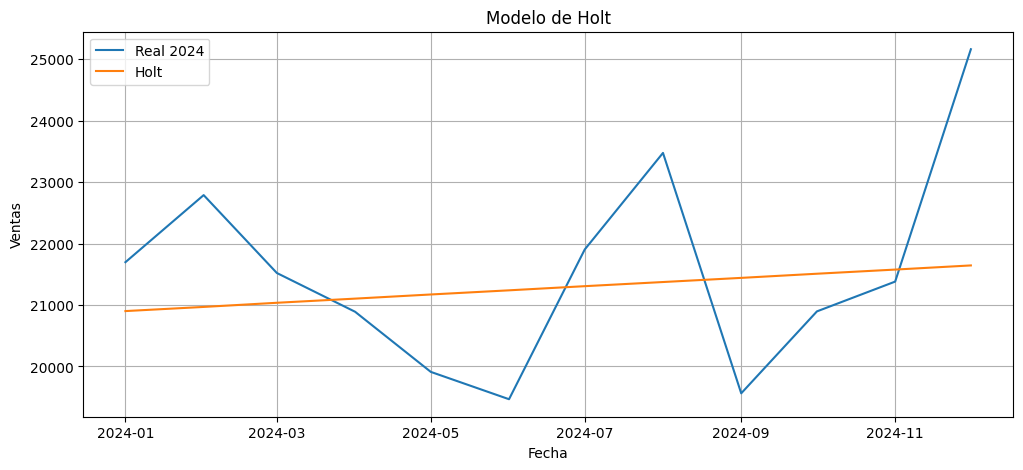

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    test_holt["Date_Value"],
    test_holt["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_holt["Date_Value"],
    test_holt["Pronostico"],
    label="Holt"
)

plt.title("Modelo de Holt")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [28]:
error = test_holt["Actual_Sales"] - test_holt["Pronostico"]
error_absoluto = abs(error)

mae_holt = error_absoluto.mean()
rmse_holt = np.sqrt((error ** 2).mean())
mape_holt = (error_absoluto / test_holt["Actual_Sales"]).mean() * 100
wape_holt = (error_absoluto.sum() / test_holt["Actual_Sales"].sum()) * 100

print("MAE:", mae_holt)
print("RMSE:", rmse_holt)
print("MAPE:", mape_holt)
print("WAPE:", wape_holt)

MAE: 1271.3069573070545
RMSE: 1583.0077717536087
MAPE: 5.791062403912229
WAPE: 5.897762579854817


# MODELO 6 — HOLT-WINTERS ADITIVO

Considera nivel, tendencia y estacionalidad.

In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw_aditivo = ExponentialSmoothing(
    train["Actual_Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

pronostico_hw_aditivo = modelo_hw_aditivo.forecast(len(test))

test_hw_aditivo = test.copy()
test_hw_aditivo["Pronostico"] = pronostico_hw_aditivo.values

### Gráfico

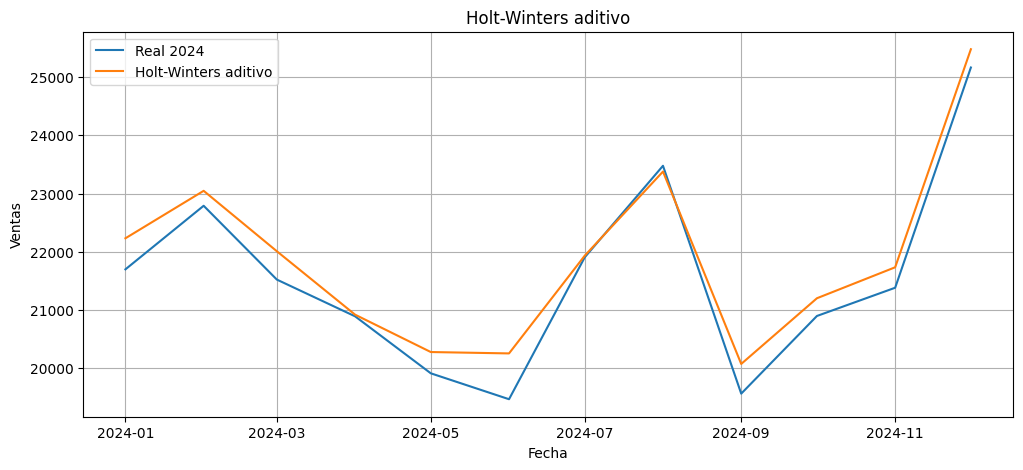

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    test_hw_aditivo["Date_Value"],
    test_hw_aditivo["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_hw_aditivo["Date_Value"],
    test_hw_aditivo["Pronostico"],
    label="Holt-Winters aditivo"
)

plt.title("Holt-Winters aditivo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [31]:
error = test_hw_aditivo["Actual_Sales"] - test_hw_aditivo["Pronostico"]
error_absoluto = abs(error)

mae_hw_aditivo = error_absoluto.mean()
rmse_hw_aditivo = np.sqrt((error ** 2).mean())
mape_hw_aditivo = (error_absoluto / test_hw_aditivo["Actual_Sales"]).mean() * 100
wape_hw_aditivo = (error_absoluto.sum() / test_hw_aditivo["Actual_Sales"].sum()) * 100

print("MAE:", mae_hw_aditivo)
print("RMSE:", rmse_hw_aditivo)
print("MAPE:", mape_hw_aditivo)
print("WAPE:", wape_hw_aditivo)

MAE: 338.8314315962231
RMSE: 400.7305837513828
MAPE: 1.6142666729391575
WAPE: 1.5718842146351812


# MODELO 7 — HOLT-WINTERS MULTIPLICATIVO

Aquí la estacionalidad cambia proporcionalmente con el nivel de la demanda.

In [32]:
modelo_hw_multiplicativo = ExponentialSmoothing(
    train["Actual_Sales"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

pronostico_hw_multiplicativo = modelo_hw_multiplicativo.forecast(len(test))

test_hw_multiplicativo = test.copy()
test_hw_multiplicativo["Pronostico"] = pronostico_hw_multiplicativo.values

### Gráfico

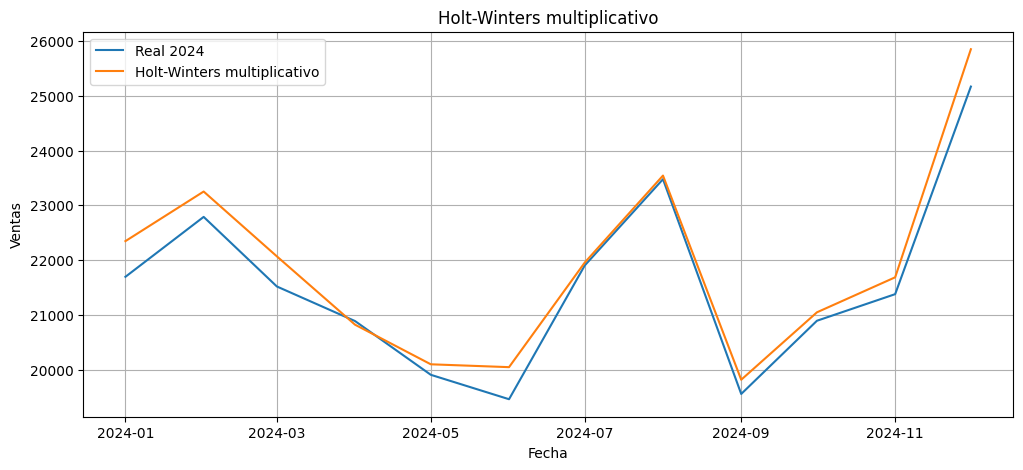

In [33]:
plt.figure(figsize=(12,5))

plt.plot(
    test_hw_multiplicativo["Date_Value"],
    test_hw_multiplicativo["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_hw_multiplicativo["Date_Value"],
    test_hw_multiplicativo["Pronostico"],
    label="Holt-Winters multiplicativo"
)

plt.title("Holt-Winters multiplicativo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [34]:
error = test_hw_multiplicativo["Actual_Sales"] - test_hw_multiplicativo["Pronostico"]
error_absoluto = abs(error)

mae_hw_multiplicativo = error_absoluto.mean()
rmse_hw_multiplicativo = np.sqrt((error ** 2).mean())
mape_hw_multiplicativo = (error_absoluto / test_hw_multiplicativo["Actual_Sales"]).mean() * 100
wape_hw_multiplicativo = (error_absoluto.sum() / test_hw_multiplicativo["Actual_Sales"].sum()) * 100

print("MAE:", mae_hw_multiplicativo)
print("RMSE:", rmse_hw_multiplicativo)
print("MAPE:", mape_hw_multiplicativo)
print("WAPE:", wape_hw_multiplicativo)

MAE: 335.28039293161027
RMSE: 405.83919788887954
MAPE: 1.548454181386412
WAPE: 1.5554104725264035


# MODELO 8 — DESCOMPOSICIÓN

Reproduce la lógica del Excel:

**Pronóstico = Tendencia × Índice estacional**

## Crear período

In [35]:
train_dec = train.copy()
train_dec["t"] = range(1, len(train_dec) + 1)

## Calcular tendencia

In [36]:
n = len(train_dec)

sum_t = train_dec["t"].sum()
sum_y = train_dec["Actual_Sales"].sum()
sum_ty = (train_dec["t"] * train_dec["Actual_Sales"]).sum()
sum_t2 = (train_dec["t"] ** 2).sum()

b1 = (
    n * sum_ty - sum_t * sum_y
) / (
    n * sum_t2 - sum_t ** 2
)

b0 = (
    sum_y - b1 * sum_t
) / n

print("Pendiente:", b1)
print("Intercepto:", b0)

Pendiente: 98.97477477477477
Intercepto: 17637.133333333335


## Aplicar tendencia

In [37]:
train_dec["Tendencia"] = b0 + b1 * train_dec["t"]

## Calcular índice estacional

In [38]:
train_dec["Indice_Estacional"] = (
    train_dec["Actual_Sales"] /
    train_dec["Tendencia"]
)

indices_estacionales = (
    train_dec
    .groupby(train_dec["Date_Value"].dt.month)
    ["Indice_Estacional"]
    .mean()
    .reset_index()
)

indices_estacionales.columns = [
    "Mes",
    "Indice_Estacional"
]

indices_estacionales

,Mes,Indice_Estacional
0,1,1.047422
1,2,1.084904
2,3,1.024962
3,4,0.963312
4,5,0.924583
5,6,0.919262
6,7,0.999252
7,8,1.068951
8,9,0.895956
9,10,0.949552


## Gráfico de índices

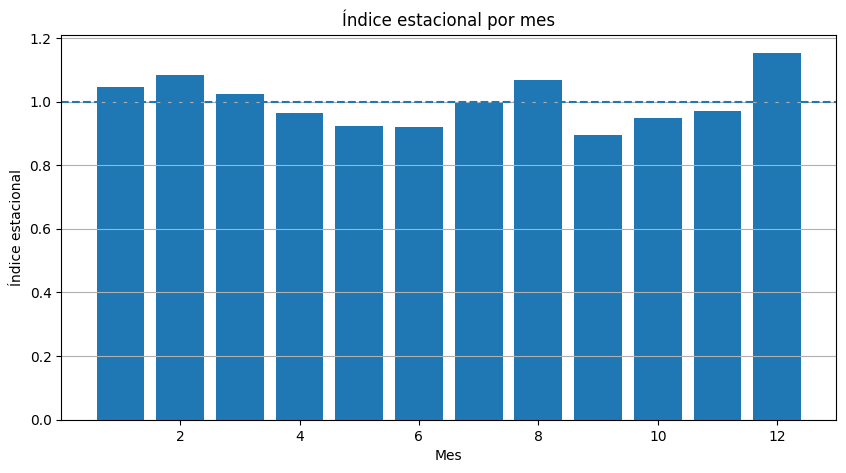

In [39]:
plt.figure(figsize=(10,5))

plt.bar(
    indices_estacionales["Mes"],
    indices_estacionales["Indice_Estacional"]
)

plt.axhline(1, linestyle="--")

plt.title("Índice estacional por mes")
plt.xlabel("Mes")
plt.ylabel("Índice estacional")
plt.grid(axis="y")
plt.show()

## Crear pronóstico 2024

In [40]:
test_dec = test.copy()

test_dec["t"] = range(
    len(train_dec) + 1,
    len(train_dec) + len(test_dec) + 1
)

test_dec["Mes"] = test_dec["Date_Value"].dt.month

test_dec["Tendencia"] = b0 + b1 * test_dec["t"]

test_dec = test_dec.merge(
    indices_estacionales,
    on="Mes",
    how="left"
)

test_dec["Pronostico"] = (
    test_dec["Tendencia"] *
    test_dec["Indice_Estacional"]
)

Ver resultados:

In [41]:
test_dec[
    [
        "Date_Value",
        "Actual_Sales",
        "Tendencia",
        "Indice_Estacional",
        "Pronostico"
    ]
]

,Date_Value,Actual_Sales,Tendencia,Indice_Estacional,Pronostico
0,2024-01-01,21698,21299.200000,1.047422,22309.245383
1,2024-02-01,22790,21398.174775,1.084904,23214.960684
2,2024-03-01,21522,21497.149550,1.024962,22033.758529
3,2024-04-01,20891,21596.124324,0.963312,20803.805646
4,2024-05-01,19912,21695.099099,0.924583,20058.918632
5,2024-06-01,19467,21794.073874,0.919262,20034.469104
6,2024-07-01,21905,21893.048649,0.999252,21876.672900
7,2024-08-01,23477,21992.023423,1.068951,23508.391327
8,2024-09-01,19563,22090.998198,0.895956,19792.560616
9,2024-10-01,20897,22189.972973,0.949552,21070.536890


## Gráfico

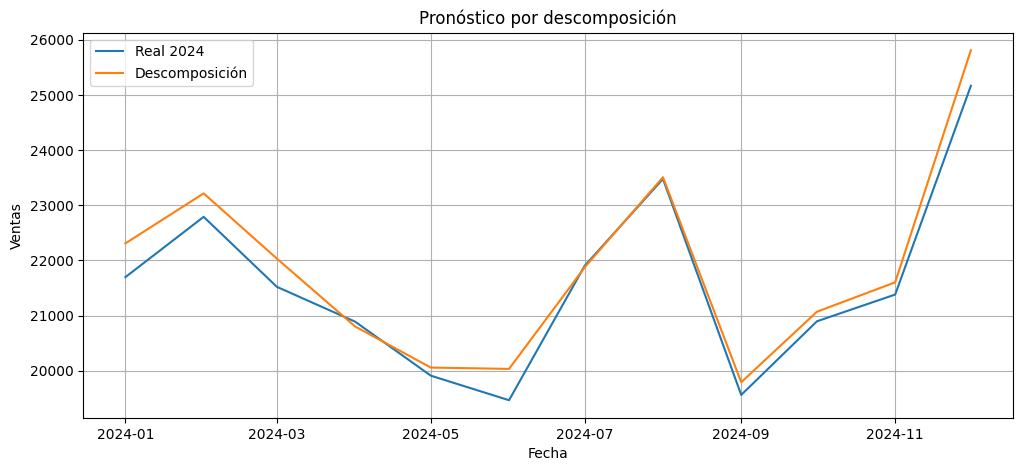

In [42]:
plt.figure(figsize=(12,5))

plt.plot(
    test_dec["Date_Value"],
    test_dec["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_dec["Date_Value"],
    test_dec["Pronostico"],
    label="Descomposición"
)

plt.title("Pronóstico por descomposición")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

## Evaluación

In [43]:
error = test_dec["Actual_Sales"] - test_dec["Pronostico"]
error_absoluto = abs(error)

mae_descomposicion = error_absoluto.mean()
rmse_descomposicion = np.sqrt((error ** 2).mean())
mape_descomposicion = (error_absoluto / test_dec["Actual_Sales"]).mean() * 100
wape_descomposicion = (error_absoluto.sum() / test_dec["Actual_Sales"].sum()) * 100

print("MAE:", mae_descomposicion)
print("RMSE:", rmse_descomposicion)
print("MAPE:", mape_descomposicion)
print("WAPE:", wape_descomposicion)

MAE: 306.5280338066156
RMSE: 378.2024137153884
MAPE: 1.4161292730738775
WAPE: 1.4220244426968005


# MODELO 9 — SARIMA

Modelo estadístico que incorpora comportamiento temporal y estacionalidad.

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarima = SARIMAX(
    train["Actual_Sales"],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

pronostico_sarima = modelo_sarima.forecast(
    steps=len(test)
)

test_sarima = test.copy()
test_sarima["Pronostico"] = pronostico_sarima.values

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


### Gráfico

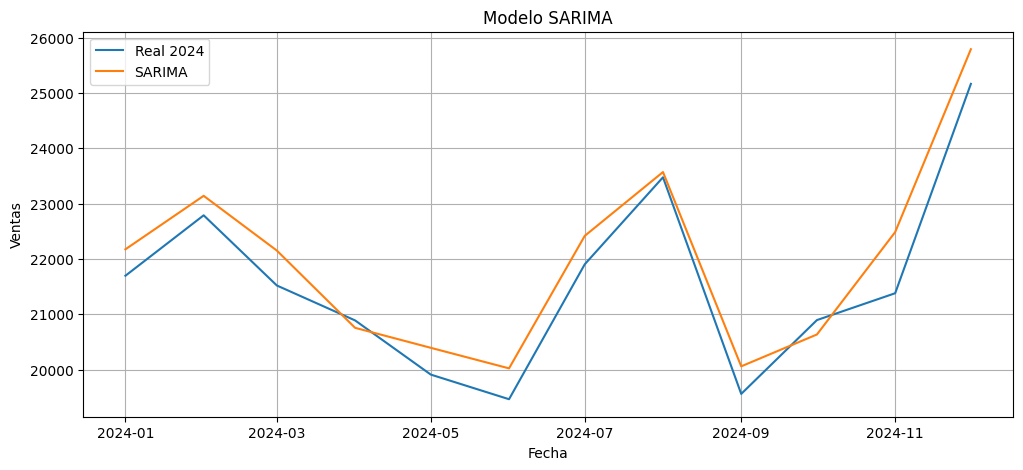

In [45]:
plt.figure(figsize=(12,5))

plt.plot(
    test_sarima["Date_Value"],
    test_sarima["Actual_Sales"],
    label="Real 2024"
)

plt.plot(
    test_sarima["Date_Value"],
    test_sarima["Pronostico"],
    label="SARIMA"
)

plt.title("Modelo SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

### Evaluación

In [46]:
error = test_sarima["Actual_Sales"] - test_sarima["Pronostico"]
error_absoluto = abs(error)

mae_sarima = error_absoluto.mean()
rmse_sarima = np.sqrt((error ** 2).mean())
mape_sarima = (error_absoluto / test_sarima["Actual_Sales"]).mean() * 100
wape_sarima = (error_absoluto.sum() / test_sarima["Actual_Sales"].sum()) * 100

print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima)
print("WAPE:", wape_sarima)

MAE: 477.7311668736308
RMSE: 541.1014985428891
MAPE: 2.233671254014615
WAPE: 2.2162586171839567


> Nota: tenemos solamente 36 meses de entrenamiento. SARIMA puede mostrar advertencias de estimación con una serie tan corta.

# COMPARACIÓN FINAL

In [47]:
resultados = pd.DataFrame({
    "Modelo": [
        "Naive",
        "Seasonal Naive",
        "Promedio móvil",
        "SES",
        "Holt",
        "Holt-Winters aditivo",
        "Holt-Winters multiplicativo",
        "Descomposición",
        "SARIMA"
    ],

    "MAE": [
        mae_naive,
        mae_seasonal,
        mae_ma,
        mae_ses,
        mae_holt,
        mae_hw_aditivo,
        mae_hw_multiplicativo,
        mae_descomposicion,
        mae_sarima
    ],

    "RMSE": [
        rmse_naive,
        rmse_seasonal,
        rmse_ma,
        rmse_ses,
        rmse_holt,
        rmse_hw_aditivo,
        rmse_hw_multiplicativo,
        rmse_descomposicion,
        rmse_sarima
    ],

    "MAPE": [
        mape_naive,
        mape_seasonal,
        mape_ma,
        mape_ses,
        mape_holt,
        mape_hw_aditivo,
        mape_hw_multiplicativo,
        mape_descomposicion,
        mape_sarima
    ],

    "WAPE": [
        wape_naive,
        wape_seasonal,
        wape_ma,
        wape_ses,
        wape_holt,
        wape_hw_aditivo,
        wape_hw_multiplicativo,
        wape_descomposicion,
        wape_sarima
    ]
})

resultados

,Modelo,MAE,RMSE,MAPE,WAPE
0,Naive,3160.916667,3458.292028,15.202461,14.663914
1,Seasonal Naive,3248.583333,3270.538424,15.086429,15.070611
2,Promedio móvil,1620.991923,1928.304085,7.737752,7.519998
3,SES,1231.040428,1625.148738,5.570464,5.710961
4,Holt,1271.306957,1583.007772,5.791062,5.897763
5,Holt-Winters aditivo,338.831432,400.730584,1.614267,1.571884
6,Holt-Winters multiplicativo,335.280393,405.839198,1.548454,1.555410
7,Descomposición,306.528034,378.202414,1.416129,1.422024
8,SARIMA,477.731167,541.101499,2.233671,2.216259


## Ordenar por WAPE

In [48]:
resultados.sort_values("WAPE")

,Modelo,MAE,RMSE,MAPE,WAPE
7,Descomposición,306.528034,378.202414,1.416129,1.422024
6,Holt-Winters multiplicativo,335.280393,405.839198,1.548454,1.555410
5,Holt-Winters aditivo,338.831432,400.730584,1.614267,1.571884
8,SARIMA,477.731167,541.101499,2.233671,2.216259
3,SES,1231.040428,1625.148738,5.570464,5.710961
4,Holt,1271.306957,1583.007772,5.791062,5.897763
2,Promedio móvil,1620.991923,1928.304085,7.737752,7.519998
0,Naive,3160.916667,3458.292028,15.202461,14.663914
1,Seasonal Naive,3248.583333,3270.538424,15.086429,15.070611


## Gráfico de WAPE

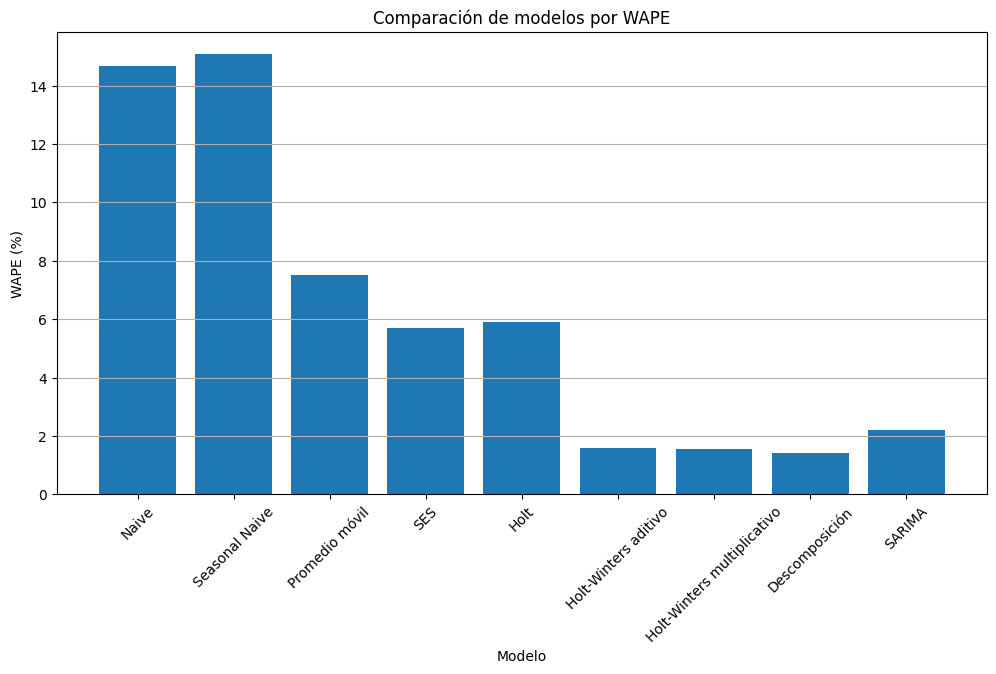

In [49]:
plt.figure(figsize=(12,6))

plt.bar(
    resultados["Modelo"],
    resultados["WAPE"]
)

plt.title("Comparación de modelos por WAPE")
plt.xlabel("Modelo")
plt.ylabel("WAPE (%)")

plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## Comparación visual de todos los modelos

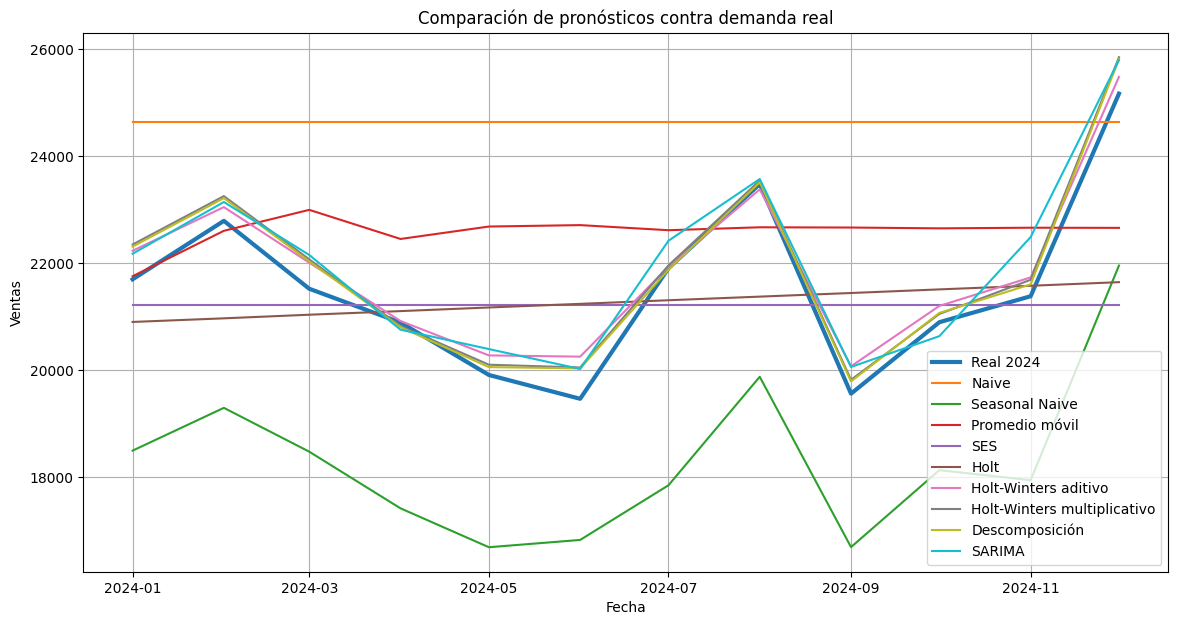

In [50]:
plt.figure(figsize=(14,7))

plt.plot(
    test["Date_Value"],
    test["Actual_Sales"],
    label="Real 2024",
    linewidth=3
)

plt.plot(test_naive["Date_Value"], test_naive["Pronostico"], label="Naive")
plt.plot(test_seasonal["Date_Value"], test_seasonal["Pronostico"], label="Seasonal Naive")
plt.plot(test_ma["Date_Value"], test_ma["Pronostico"], label="Promedio móvil")
plt.plot(test_ses["Date_Value"], test_ses["Pronostico"], label="SES")
plt.plot(test_holt["Date_Value"], test_holt["Pronostico"], label="Holt")
plt.plot(test_hw_aditivo["Date_Value"], test_hw_aditivo["Pronostico"], label="Holt-Winters aditivo")
plt.plot(test_hw_multiplicativo["Date_Value"], test_hw_multiplicativo["Pronostico"], label="Holt-Winters multiplicativo")
plt.plot(test_dec["Date_Value"], test_dec["Pronostico"], label="Descomposición")
plt.plot(test_sarima["Date_Value"], test_sarima["Pronostico"], label="SARIMA")

plt.title("Comparación de pronósticos contra demanda real")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid()
plt.show()

# CONCLUSIÓN

En este proyecto se estudian modelos clásicos de pronóstico de demanda en Python:

1. Naive
2. Seasonal Naive
3. Promedio móvil
4. Suavizamiento exponencial simple
5. Holt
6. Holt-Winters aditivo
7. Holt-Winters multiplicativo
8. Descomposición
9. SARIMA

No se utiliza Machine Learning.

El objetivo es entender primero la lógica de los modelos clásicos y luego comparar sus errores mediante MAE, RMSE, MAPE y WAPE.